# EGBE: modelling the evolution gravel-sized alluvium layer and the underlying bedrock in a network of rivers

### This notebook provides a brief introduction and user’s guide to the Extended Gravel Bed Eroder (EGBE) Landlabs' component. The model simulates drainage network evolution for a network of rivers that have a layer of gravel alluvium overlying bedrock, taking into account heterogeneous sizes OR hardness of the gravels. EGBE relies on an additional Landlab components that handle flow routing (for exampple FlowAccumulator) and track the mass of hetrogenoues sediment layer (SoilGrading).

### EGBE is an advanced version of the Gravel Bedrock Eroder model (GBE) decribed in the following publication:

* Gabel, V., Tucker, G. E., & Campforts, B. (2024). A mathematical model for bedrock incision in near‐threshold gravel‐bed rivers. Earth Surface Processes and Landforms, 49(13), 4168-4186.




# EGBE Model description

## Input parameters
* grid : ModelGrid
    A Landlab model grid object
* intermittency_factor : float (default 0.01)
    Fraction of time that bankfull flow occurs
* sediment_porosity : float (default 0.35)
    Bulk porosity of bed sediment
* depth_decay_scale : float (default 1.0)
    Scale for depth decay in bedrock exposure function
* plucking_coefficient : float or (n_core_nodes,) array of float (default 1.0e-4 1/m)
    Rate coefficient for bedrock erosion by plucking
* epsilon : float (default 0.2)
    Near-threshold coefficient
* abrasion_coefficient : float (default 0.0 1/m) *DEPRECATED*
    Abrasion coefficient with units of inverse length
* bedrock_abrasion_coefficients : float (default 0)
    Abrasion coefficient for bedrock
* fractions_from_plucking : float (default 1)
    The mass fraction that is plucked from the bedrock for each sediment class
* rho_sed : float (default 2650)
    Density of the alluvial layer
* rho_water : float (default 1000)
    Density of the fluid
* use_fixed_width : Boolean (default True)
    Flag that if set to true, EGBE run under fixed-width model. If set to false,
    EGBE run under dynamic-width model (default true).
* width_coeff : float (default 0.002)
    Empirical coefficient for channel width;
    NOTE: units, if exponent is 1/2: 1/(m^0.5*s^0.5) -- need to make this conversion to years, not seconds
* width_expt : float (default 0.5)
    Empirical exponent for channel width;
* mannings_n : float (default 0.05)
    Manning's roughness coeffcient
* tau_star_c_median : float (default 0.045)
    Dimensionless critical shear stress for transport of median grain size
* alpha : float (default 0.68)
    Empirical exponent for critical shear stress
* tau_c_bedrock : float (default 10)
    Critical shear stress for bedrock plucking
* d_min : float (default 0.1)
    Immobile depth of alluvial layer
* plucking_by_tools_flag : Boolean (default False)
    A flag



## Model fields

#### Below are listed fields updated by the component at the grid locations. Other fields handled by other Landlab components, used by EGBE but that are not updated by it are: `flow__link_to_receiver_node`, `flow__receiver_node`, `flow__upstream_node_order`, `surface_water__discharge`, `topographic__steepest_slope`

* `bedrock__elevation` [m]: elevation of the bedrock surface
* `soil__depth` [m]: Depth of soil or weathered bedrock
* `topographic__elevation` [m]: Land surface topographic elevation
* `grains__weight` [$kg/m^{2}$]: Mass per unit area of grains in each size class stored at node
* `bedload_sediment__rate_of_loss_to_abrasion` [m/y]: Rate of bedload sediment volume loss to abrasion per unit area
* `bedload_sediment__volume_influx` [$m^{3}/y$]: Volumetric incoming streamwise bedload sediment transport rate
* `bedload_sediment__volume_outflux`[$m^{3}/y$]: Volumetric outgoing streamwise bedload sediment transport rate
* `bedrock__abrasion_rate` [m/y]: rate of bedrock lowering by abrasion
* `bedrock__exposure_fraction`[-]: fractional exposure of bedrock
* `bedrock__plucking_rate` [m/y]: rate of bedrock lowering by plucking
* `bedrock__lowering_rate` [m/y]: Rate of lowering of bedrock surface
* `sediment__rate_of_change` [m/y]: Time rate of change of sediment thickness

# Background on SoilGrading component

### SoilGrading component track sediment mass of diffrent classes and simulates their grading/fragmentation due to weathering based on the mARM (Cohen et al., 2009, 2010) model. The fragmentation process is controlled by a weathering transition matrix which defines the relative mass change in each soil grain size class (grading class) as a result of the fracturing of particles in the weathering mechanism.

### Publications:
*   Cohen, S., Willgoose, G., & Hancock, G. (2009). The mARM spatially distributed soil
    evolution model: A computationally efficient modeling framework and analysis of
    hillslope soil surface organization. Journal of Geophysical Research: Earth Surface,
    114(F3).

*   Cohen, S., Willgoose, G., & Hancock, G. (2010). The mARM3D spatially distributed
    soil evolution model: Three‐dimensional model framework and analysis of hillslope
    and landform responses. Journal of Geophysical Research: Earth Surface, 115(F4).
    

In [42]:
from landlab.components import ExtendedGravelBedrockEroder
from landlab.components.soil_grading import SoilGrading
from landlab.components import PriorityFloodFlowRouter, FlowAccumulator
from landlab import RasterModelGrid, HexModelGrid
import matplotlib.pyplot as plt
from landlab.components import BedrockLandslider
import numpy as np
from landlab import imshow_grid
from landlab.components import ChannelProfiler

In [43]:
def init_components(grid,
                    meansizes = 0.03,
                    grains_weight = 0,
                    phi = 0.4,
                    sediment_density = 2650,
                    bed_grains_proportions = 1,
                    runoff_rate = 5.0,
                    intermittency_factor = 0.1,
                    depth_decay_scale = 1,
                    plucking_coefficient = 1,
                    abrasion_coefficients = 0,
                    bedrock_abrasion_coefficient = 0,
                    rho_water = 1000,
                    use_fixed_width = True,
                    fixed_width_coeff = 0.002,
                    fixed_width_expt = 0.5,
                    mannings_n = 0.05,
                    tau_star_c_median = 0.045,
                    alpha = 0.68,
                    tau_c_bedrock = 10,
                    d_min = 0.1,
                    plucking_by_tools_flag = False,
                    angle_int_frict=0.01,
                    cohesion_eff=1e2,
                    landslides_return_time=1,
                    landslides_on_boundary_nodes=False,
                    min_deposition_slope = 0.005,
                    threshold_slope=0.5,
                    init_hylands=False):



    sg = SoilGrading(grid,
                     meansizes=meansizes,
                     grains_weight=grains_weight,
                     phi=phi,
                     soil_density=sediment_density)
    sg.update_bed_grains_proportions(proportions=bed_grains_proportions)


    if init_hylands:
        print('hyland is on')
        fa = PriorityFloodFlowRouter(grid,
                                 surface="topographic__elevation",
                                 accumulate_flow=True,
                                 runoff_rate=runoff_rate,
                                 flow_metric='D8',
                                 update_flow_depressions=True,
                                 depression_handler='fill',
                                 epsilon=True,
                                     separate_hill_flow=True)
    else:

        if isinstance(grid,HexModelGrid):
            flow_director='FlowDirectorSteepest'
        else:
            flow_director='D8'
        fa = FlowAccumulator(grid,surface="topographic__elevation",
                             runoff_rate=runoff_rate,
                             depression_finder="DepressionFinderAndRouter",
                             flow_director=flow_director)


    
    # Init eroder
    eroder = ExtendedGravelBedrockEroder(grid,
                                         intermittency_factor=intermittency_factor,
                                         sediment_porosity=phi,
                                         depth_decay_scale=depth_decay_scale ,
                                         plucking_coefficient=plucking_coefficient,
                                         abrasion_coefficients=abrasion_coefficients,
                                         bedrock_abrasion_coefficient=bedrock_abrasion_coefficient,
                                         fractions_from_plucking=bed_grains_proportions,
                                         rho_sed=sediment_density,
                                         rho_water=rho_water,
                                         use_fixed_width=use_fixed_width,
                                         fixed_width_coeff=fixed_width_coeff,
                                         fixed_width_expt=fixed_width_expt,
                                         mannings_n=mannings_n,
                                         tau_star_c_median=tau_star_c_median,
                                         alpha=alpha,
                                         tau_c_bedrock=tau_c_bedrock,
                                         d_min=d_min,
                                         plucking_by_tools_flag=plucking_by_tools_flag
                                         )
    
    hy=init_hylands
    if init_hylands:

        hy = BedrockLandslider(
            grid,
            angle_int_frict=angle_int_frict,
            cohesion_eff=cohesion_eff,
            landslides_return_time=landslides_return_time,
            rho_r = sediment_density,
            phi = phi,
            landslides_on_boundary_nodes=landslides_on_boundary_nodes,
            min_deposition_slope=min_deposition_slope,
            threshold_slope=threshold_slope)


    return grid, sg, fa, eroder, hy

In [44]:
def create_1d_grid(n_rows=62,
                   n_cols=3,
                   spacing=5000,
                   init_slope=0.001):
        
    grid = RasterModelGrid((n_rows, n_cols), xy_spacing=spacing)
    # Create fields
    topo = grid.add_zeros('topographic__elevation', at='node')
    rock_elev = grid.add_zeros('bedrock__elevation', at='node')
    soil_depth = grid.add_zeros('soil__depth', at='node')
    
    # Set boundaries and initial topography
    grid.set_watershed_boundary_condition_outlet_id(grid.nodes[0, 1],'topographic__elevation')
    rock_elev[:] += grid.y_of_node * init_slope 

    return grid, topo, rock_elev,  soil_depth



def create_2d_grid(n_rows=50,
                   n_cols=50,
                   spacing=5000,
                   init_slope=0.001,
                  hex_grid =True):
                   # Create grid

    if hex_grid:
        grid = HexModelGrid((n_rows, n_cols),
                            spacing=spacing,
                            node_layout="rect")
        grid.status_at_node[grid.nodes_at_left_edge]=grid.BC_NODE_IS_CLOSED
        grid.status_at_node[grid.nodes_at_right_edge]=grid.BC_NODE_IS_CLOSED
        grid.status_at_node[grid.nodes_at_top_edge]=grid.BC_NODE_IS_CLOSED
        grid.status_at_node[grid.nodes_at_bottom_edge] = grid.BC_NODE_IS_FIXED_VALUE
    else:
        grid = RasterModelGrid((n_rows, n_cols), xy_spacing=spacing)
        grid.set_closed_boundaries_at_grid_edges(right=True, top=True, left=True, bottom=False)
        
    # Create fields
    topo = grid.add_zeros('topographic__elevation', at='node')
    rock_elev = grid.add_zeros('bedrock__elevation', at='node')
    soil_depth = grid.add_zeros('soil__depth', at='node')
    
    # Set boundaries and initial topography
    rock_elev[:] += grid.y_of_node * init_slope
    topo[:] = soil_depth[:] + rock_elev[:]
    
    return grid, topo, rock_elev,  soil_depth

In [45]:
def plot_profile(ax, grid, color='black',
                sqrmeter_to_sqrkm=True,
                convert_m_to_km=True,
                label = ''):

    xvec = grid.y_of_node[grid.core_nodes]
    if convert_m_to_km:
        xvec /= 1000
    ax[0].plot(xvec, grid.at_node['topographic__elevation'][grid1.core_nodes],color=color,
              label=label)
    
    ax[0].set_xlabel('Distance upstream [km]')
    ax[0].set_ylabel('Elevation [m]')


    if sqrmeter_to_sqrkm:
        a_factor =1000**2
    else:
        a_factor=1
        
    plt.axes(ax[1])
    plt.loglog(
        grid.at_node["drainage_area"][grid.core_nodes]/a_factor,
        grid.at_node["topographic__steepest_slope"][grid.core_nodes],
        ".",
        color=color,
        lw=2,label=label
    )
    
    ax[1].set_ylabel('Slope [m/m]')
    ax[1].set_xlabel('Area [$m^{2}$]')

In [46]:
# Create a 1D grid
grid, topo, rock_elev,  soil_depth =  create_1d_grid()

# Initialize the components 
abrasion_coefficients=10**-4
grid, sg, fa, eroder, hy = init_components(grid, abrasion_coefficients=abrasion_coefficients)

SD already exists


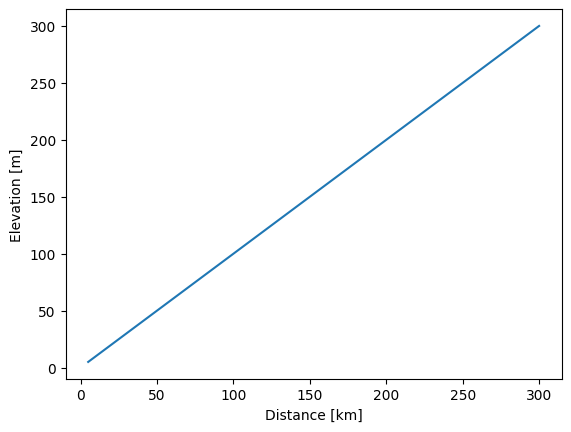

In [47]:
# Lets have a look at the initial topography 
xvec = grid.y_of_node[grid.core_nodes]/1000
plt.plot(xvec, grid.at_node['topographic__elevation'][grid.core_nodes])
plt.xlabel('Distance [km]')
plt.ylabel('Elevation [m]')
plt.show()

In [48]:
# Now, lets run two EGBE models.
# One with "soft" and another with "hard" sediments
grid1, topo1, rock_elev1,  soil_depth1 =  create_1d_grid()
grid2, topo2, rock_elev2,  soil_depth2 =  create_1d_grid()

abrasion_coefficients1 = 10**-3
abrasion_coefficients2 = 10**-5

grid1, sg1, fa1, eroder1, hy1 = init_components(grid1, abrasion_coefficients=abrasion_coefficients1)
grid2, sg2, fa2, eroder2, hy2 = init_components(grid2, abrasion_coefficients = abrasion_coefficients2)

SD already exists
SD already exists


In [49]:
uplift_rate = 10**-3
timestep=500
total_time = int(3e6)
for i in range(0,total_time,timestep):

    fa1.run_one_step()
    eroder1.run_one_step(1*timestep)
    grid1.at_node['bedrock__elevation'][grid1.core_nodes]+=uplift_rate*timestep

    fa2.run_one_step()
    eroder2.run_one_step(1*timestep)
    grid2.at_node['bedrock__elevation'][grid2.core_nodes]+=uplift_rate*timestep
    
    if np.mod(i,1e5)==0:
        print(np.round((i/total_time)*100,1), '% completed')
print(np.round((i/total_time)*100,1), '% completed')

0.0 % completed
3.3 % completed
6.7 % completed
10.0 % completed
13.3 % completed
16.7 % completed
20.0 % completed
23.3 % completed
26.7 % completed
30.0 % completed
33.3 % completed
36.7 % completed
40.0 % completed
43.3 % completed
46.7 % completed
50.0 % completed
53.3 % completed
56.7 % completed
60.0 % completed
63.3 % completed
66.7 % completed
70.0 % completed
73.3 % completed
76.7 % completed
80.0 % completed
83.3 % completed
86.7 % completed
90.0 % completed
93.3 % completed
96.7 % completed
100.0 % completed


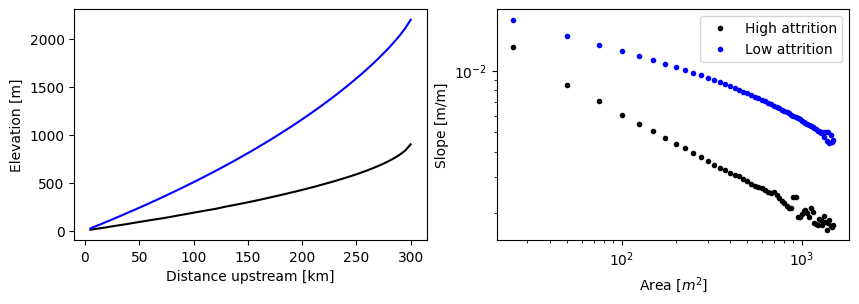

In [50]:
fig,ax = plt.subplots(1,2,figsize=(10,3))
plot_profile(ax, grid1, color='black',label='High attrition')
plot_profile(ax, grid2, color='blue', label= 'Low attrition')
plt.legend()
plt.show()

In [58]:
# Run two EGBE models with two diffrent bedrock abrasion coeffs
grid1, topo1, rock_elev1,  soil_depth1 =  create_1d_grid()
grid2, topo2, rock_elev2,  soil_depth2 =  create_1d_grid()

abrasion_coefficients1 = 10**-2.5
abrasion_coefficients2 = 10**-6

grid1, sg1, fa1, eroder1, hy1 = init_components(grid1,
                                                abrasion_coefficients=abrasion_coefficients2,
                                                bedrock_abrasion_coefficient=abrasion_coefficients1)

                                                
grid2, sg2, fa2, eroder2, hy2 = init_components(grid2,
                                                abrasion_coefficients = abrasion_coefficients1,
                                                bedrock_abrasion_coefficient=abrasion_coefficients1)

SD already exists
SD already exists


In [59]:
uplift_rate = 10**-3
timestep=500
total_time = int(6e6)
for i in range(0,total_time,timestep):

    fa1.run_one_step()
    eroder1.run_one_step(1*timestep)
    grid1.at_node['bedrock__elevation'][grid1.core_nodes]+=uplift_rate*timestep

    fa2.run_one_step()
    eroder2.run_one_step(1*timestep)
    grid2.at_node['bedrock__elevation'][grid2.core_nodes]+=uplift_rate*timestep
    
    if np.mod(i,1e5)==0:
        print(np.round((i/total_time)*100,1), '% completed')
print(np.round((i/total_time)*100,1), '% completed')

0.0 % completed
1.7 % completed
3.3 % completed
5.0 % completed
6.7 % completed
8.3 % completed
10.0 % completed
11.7 % completed
13.3 % completed
15.0 % completed
16.7 % completed
18.3 % completed
20.0 % completed
21.7 % completed
23.3 % completed
25.0 % completed
26.7 % completed
28.3 % completed
30.0 % completed
31.7 % completed
33.3 % completed
35.0 % completed
36.7 % completed
38.3 % completed
40.0 % completed
41.7 % completed
43.3 % completed
45.0 % completed
46.7 % completed
48.3 % completed
50.0 % completed
51.7 % completed
53.3 % completed
55.0 % completed
56.7 % completed
58.3 % completed
60.0 % completed
61.7 % completed
63.3 % completed
65.0 % completed
66.7 % completed
68.3 % completed
70.0 % completed
71.7 % completed
73.3 % completed
75.0 % completed
76.7 % completed
78.3 % completed
80.0 % completed
81.7 % completed
83.3 % completed
85.0 % completed
86.7 % completed
88.3 % completed
90.0 % completed
91.7 % completed
93.3 % completed
95.0 % completed
96.7 % completed
98.

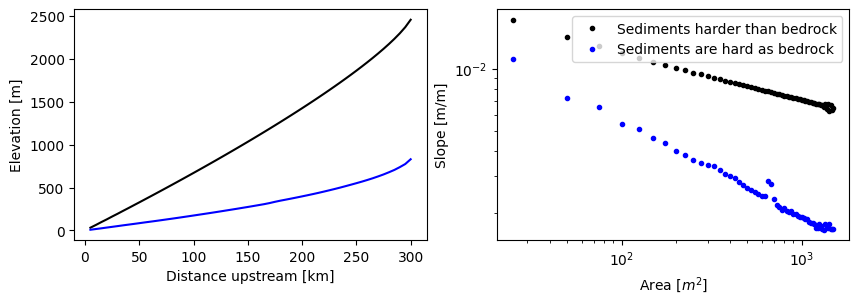

In [61]:
fig,ax = plt.subplots(1,2,figsize=(10,3))
plot_profile(ax, grid1, color='black',label= 'Sediments are harder than bedrock')
plot_profile(ax, grid2, color='blue', label= 'Sediments are hard as bedrock')
plt.legend()
plt.show()

In [62]:
# Fix width vs. Dynamic width
grid1, topo1, rock_elev1,  soil_depth1 =  create_1d_grid()
grid2, topo2, rock_elev2,  soil_depth2 =  create_1d_grid()

abrasion_coefficients1 = 10**(-4.3)
meansizes = 0.03

grid1, sg1, fa1, eroder1, hy1 = init_components(grid1,
                                                meansizes=meansizes,
                                                abrasion_coefficients=abrasion_coefficients1)

grid2, sg2, fa2, eroder2, hy2 = init_components(grid2,
                                                abrasion_coefficients=abrasion_coefficients1,
                                                meansizes=meansizes,
                                                use_fixed_width=False)

SD already exists
SD already exists


In [143]:
uplift_rate = 10**-3
timestep=100
total_time = int(3e6)

for i in range(0,total_time,timestep):
    fa1.run_one_step()
    eroder1.run_one_step(1*timestep)
    grid1.at_node['bedrock__elevation'][grid1.core_nodes]+=uplift_rate*timestep

    fa2.run_one_step()
    eroder2.run_one_step(1*timestep)
    grid2.at_node['bedrock__elevation'][grid2.core_nodes]+=uplift_rate*timestep
    
    if np.mod(i,1e5)==0:
        print(np.round((i/total_time)*100,1), '% completed')
print(np.round((i/total_time)*100,1), '% completed')

0.0 % completed
3.3 % completed
6.7 % completed
10.0 % completed
13.3 % completed
16.7 % completed
20.0 % completed
23.3 % completed
26.7 % completed
30.0 % completed
33.3 % completed
36.7 % completed
40.0 % completed
43.3 % completed
46.7 % completed
50.0 % completed
53.3 % completed
56.7 % completed
60.0 % completed
63.3 % completed
66.7 % completed
70.0 % completed
73.3 % completed
76.7 % completed
80.0 % completed
83.3 % completed
86.7 % completed
90.0 % completed
93.3 % completed
96.7 % completed
100.0 % completed


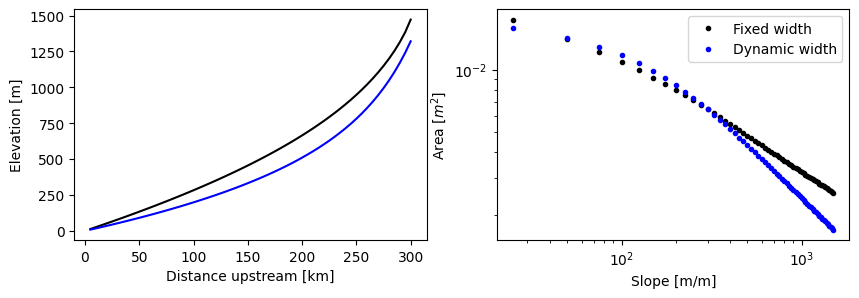

In [144]:
fig,ax = plt.subplots(1,2,figsize=(10,3))
plot_profile(ax, grid1, color='black', label='Fixed width')
plot_profile(ax, grid2, color='blue', label='Dynamic width')
plt.legend()
plt.show()

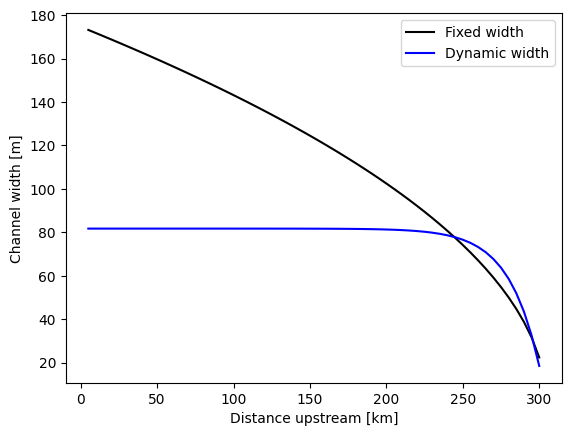

In [145]:
xvec  = grid.node_y[grid.core_nodes]/1000
plt.plot(xvec,eroder1._channel_width[grid.core_nodes],color='black',label='Fixed width')
plt.plot(xvec,eroder2._channel_width[grid.core_nodes],color='blue', label='Dynamic width')
plt.xlabel('Distance upstream [km]')
plt.ylabel('Channel width [m]')
plt.legend()
plt.show()

In [166]:
# Dynamic vs. Fixed width 2D simulations
abrasion_coefficients1 = 10**(-4.3)
meansizes = 0.03

grid1, topo1, rock_elev1,  soil_depth1 = create_2d_grid(n_rows=50, n_cols=25)
grid1, sg1, fa1, eroder1, hy1 = init_components(grid1,
                                               meansizes=meansizes,
                                                abrasion_coefficients=abrasion_coefficients1)

grid2, topo2, rock_elev2,  soil_depth2 = create_2d_grid(n_rows=50, n_cols=25)
grid2, sg2, fa2, eroder2, hy2 = init_components(grid2,
                                               abrasion_coefficients=abrasion_coefficients1,
                                                meansizes=meansizes,
                                                use_fixed_width=False,)

In [167]:
uplift_rate = 10**-3
timestep=100
total_time = int(3e5)

for i in range(0,total_time,timestep):
    fa1.run_one_step()
    eroder1.run_one_step(1*timestep)
    grid1.at_node['bedrock__elevation'][grid1.core_nodes]+=uplift_rate*timestep

    fa2.run_one_step()
    eroder2.run_one_step(1*timestep)
    grid2.at_node['bedrock__elevation'][grid2.core_nodes]+=uplift_rate*timestep
    
    if np.mod(i,1e5)==0:
        print(np.round((i/total_time)*100,1), '% completed')
print(np.round((i/total_time)*100,1), '% completed')

0.0 % completed
33.3 % completed
66.7 % completed
100.0 % completed


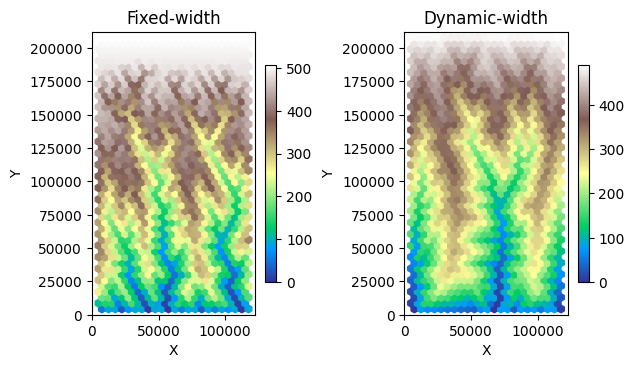

In [168]:
fig,ax = plt.subplots(1,2)
plt.axes(ax[0])
imshow_grid(grid1,'topographic__elevation',cmap='terrain', shrink=0.5)
ax[0].set_title('Fixed-width')
plt.axes(ax[1])
imshow_grid(grid2,'topographic__elevation',cmap='terrain', shrink=0.5)
ax[1].set_title('Dynamic-width')
plt.tight_layout()
plt.show()

In [149]:
profiler1 = ChannelProfiler(
    grid1,
    number_of_watersheds=2,
    minimum_channel_threshold=1000000,
    main_channel_only=False
)
profiler1.run_one_step()

profiler2 = ChannelProfiler(
    grid2,
    number_of_watersheds=2,
    minimum_channel_threshold=1000000,
    main_channel_only=False
)
profiler2.run_one_step()

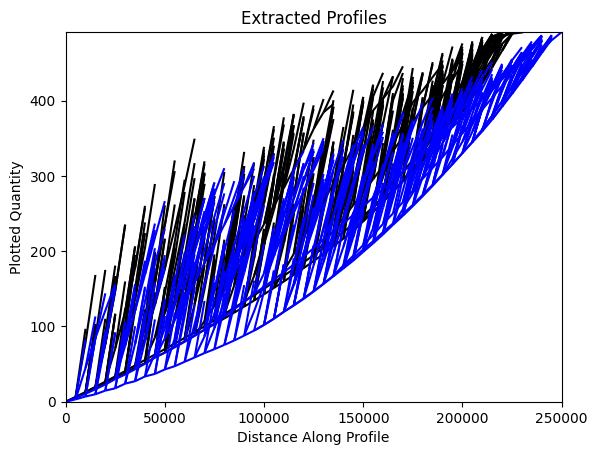

In [150]:
fig,ax =plt.subplots()
profiler1.plot_profiles(color='black')
profiler2.plot_profiles(color='blue')
plt.show()

In [174]:
## EGBE + HYLANDS
n_rows = 200
n_cols = 3
spacing = 25
init_slope = 0.1
meansizes = [0.01, 0.07] # Two classes of diffrent size
grains_weight = [0, 0]
bed_grains_proportions1=[1,0] # Bedrock breaks only into the smaller class
bed_grains_proportions2=[0,1] # Bedrock breaks only into the larger class

phi = 0.4
sediment_density = 2650
runoff_rate=10
elev_jump = 50

In [195]:
# EGBE + HYLANDS
grid1, topo1, rock_elev1,  soil_depth1 =  create_1d_grid(n_rows = n_rows, init_slope=init_slope, spacing=spacing)
grid2, topo2, rock_elev2,  soil_depth2 =  create_1d_grid(n_rows = n_rows, init_slope=init_slope, spacing=spacing)

grid1, sg1, fa1, eroder1, hy1 = init_components(grid1,
                                                bed_grains_proportions=bed_grains_proportions1,
                                                meansizes=meansizes,
                                               init_hylands = True,
                                               threshold_slope=0.5,
                                               angle_int_frict=0.5,
                                                min_deposition_slope=0.2,
                                                runoff_rate=runoff_rate,
                                               )

grid2, sg2, fa2, eroder2, hy2 = init_components(grid2,
                                                bed_grains_proportions=bed_grains_proportions2,
                                                meansizes=meansizes,
                                                init_hylands = True,
                                               threshold_slope=0.5,
                                               angle_int_frict=0.5,
                                                min_deposition_slope=0.2,
                                                runoff_rate=runoff_rate)

hyland is on
hyland is on


In [196]:
# Set boundaries and initial topography
grid1.at_node['bedrock__elevation'][grid1.core_nodes[50:]]+=elev_jump
grid2.at_node['bedrock__elevation'][grid2.core_nodes[50:]]+=elev_jump

grid1.at_node['topographic__elevation'][:] = grid1.at_node['bedrock__elevation'][:] + grid1.at_node['soil__depth'][:]
grid2.at_node['topographic__elevation'][:] = grid2.at_node['bedrock__elevation'][:] + grid2.at_node['soil__depth'][:]

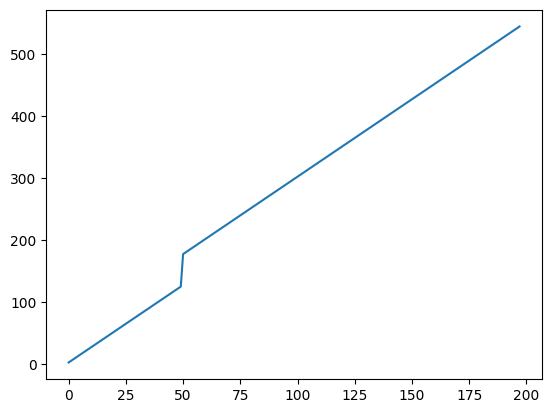

([<matplotlib.lines.Line2D at 0x17f4e6710>], None)

In [197]:
init_profile = np.copy(grid1.at_node['topographic__elevation'][grid1.core_nodes])
plt.plot(init_profile),plt.show()

In [198]:
# Iterate several times to generate landslides
for _ in range(100):
    fa1.run_one_step()
    hy1.run_one_step(dt=1e3)
    sg1.update_mass_based_on_outsource_dz()
    
    
    fa2.run_one_step()
    hy2.run_one_step(dt=1e3)
    sg2.update_mass_based_on_outsource_dz()

timestep=1
for i in range(100):
    fa1.run_one_step()
    eroder1.run_one_step(timestep)

    fa2.run_one_step()
    eroder2.run_one_step(timestep)

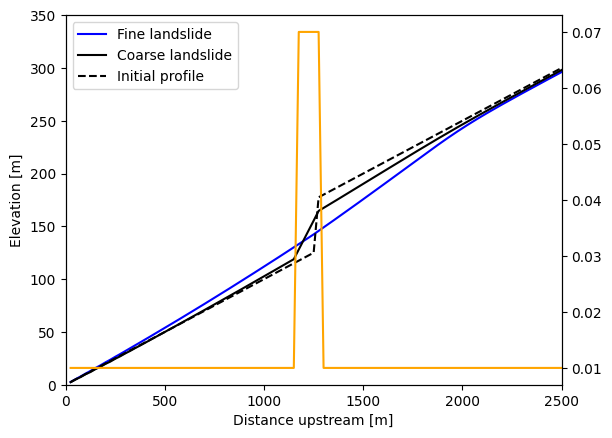

In [199]:
xspace = np.sqrt(grid1.area_of_cell)
xvec = np.cumsum(np.ones_like([grid1.core_nodes])*xspace)

fig,ax = plt.subplots()
ax.plot(xvec,
        grid1.at_node['topographic__elevation'][grid1.core_nodes],
        color='blue',
        label='Fine landslide')
ax.plot(xvec,
        grid2.at_node['topographic__elevation'][grid2.core_nodes],
        color='black',
        label='Coarse landslide')
ax.plot(xvec,
        init_profile,color='black',
        ls='--',
        label='Initial profile')

ax.set_xlim([0,2500])
ax.set_ylim([0,350])
plt.legend()

ax2 = ax.twinx()
ax2.plot(xvec, 
         grid2.at_node['median_size__weight'][grid2.core_nodes],
        color='orange')
ax.set_xlabel('Distance upstream [m]')
ax.set_ylabel('Elevation [m]')
plt.show()